#SECTION 0 — Documentation

# AMD 10-K Narrative Distress Index (RAG-style Retrieval + Market Test)

## Objective
This notebook builds narrative-based financial distress indices from AMD’s 10-K filings (Item 1A: Risk Factors) using TF-IDF retrieval. We then test whether these indices are associated with subsequent AMD abnormal returns (market-adjusted vs S&P 500).

## Data (called directly from the notebook)
All required data files are downloaded at runtime from the GitHub repo:
- `data/10k.zip` (EDGAR full-submission files for AMD 10-K, 2011–2024)
- `data/AMD.xlsx` (AMD total return index)
- `data/spx.xlsx` (S&P 500 total return index)
- `data/human_labeled.csv` (human relevance labels for retrieval evaluation)

## Pipeline Overview
1. **Data access**: download required files from GitHub (no manual file imports)
2. **Parse & preprocess**: unzip EDGAR archive → parse SGML → extract Item 1A → clean text
3. **Chunking**: sliding-window chunking (word-based, overlap)
4. **Retrieval layer**: per-year TF-IDF indexes for top-k retrieval + sanity checks
5. **Evaluation**: precision@k using human-labeled relevance data (optional)
6. **Indices**: global TF-IDF + Coverage×Intensity indices (Hard / Soft / Operational), comparable across years
7. **Market test**: merge annual indices with forward abnormal returns (6mo/12mo) and run correlations/OLS + visuals

## Outputs
Key CSV outputs generated by this notebook:
- `amd_distress_indices_global_ci.csv`
- `annual_with_indices_and_returns.csv`
- `reg_spearman_summary.csv`

```
DATA SOURCES
(10K.zip | AMD.xlsx | spx.xlsx | human_labeled.csv)
        │
        ▼
┌────────────────────┐
│ 1) Data Loader           │
│ GitHub → /data/          │
└────────────────────┘
        │
        ▼
┌──────────────-───┐
│ 2) Unzip + Discovery     │
└──────────────-───┘
        │
        ▼
┌───────────────-────┐
│ 3) Parse + Clean         │
│ SGML → Plain Text        │
└───────────────-────┘
        │
        ▼
┌──────────────────┐
│ 4) Extract Item 1A       │
└──────────────────┘
        │
        ▼
┌──────────────────┐
│ 5) Chunking           │
│ Sliding Window          │
└──────────────────┘
        │
        ▼
┌──────────────────┐
│ 6) Per-Year TF-IDF       │
│ (Retrieval Layer)        │
└──────────────────┘
   ┌─────────┴──────────┐
  ▼                     ▼
┌────────────────┐  ┌─────────────────────┐
│  7A) Top-k         │     7B) Label Table          │
│  Retrieval          │  │  Build                │
└───────┬────────┘  └──────────┬──────────┘
        ▼                      ▼
┌──────────────────┐  ┌──────────────────┐
│ 8A) Sanity            │  │ 8B) Precision@k         │
│ Check               │  │ Evaluation            │
└──────────────────┘  └──────────────────┘
        │
        ▼
┌───────────────────┐
│ 9) Global TF-IDF         │
│ (All Years)            │
└───────────────────┘
        │
        ▼
┌──────────────────┐
│ 10) Family Scoring       │
│ Hard /Soft / Oper       │
└──────────────────┘
        │
        ▼
┌──────────────────┐
│ 11) Threshold Flags       │
│ (Global Quantile)        │
└──────────────────┘
        │
        ▼
┌──────────────────┐
│ 12) Coverage × Intensity   │
│ Year-Level Indices       │
└──────────────────┘
        │
        ▼
┌───────────────────┐
│ 13) Market Merge         │
│ AMD − SPX (6M / 12M)     │
└───────────────────┘
        │
        ▼
┌─────────────────┐
│ 14) Regression + Plots    │
│ Spearman / OLS        │
└────────────----───┘
        │
        ▼
FINAL OUTPUTS
(CI indices + Returns + Tables)
 ```

|   | Section                                       | Description                                                 |
| -- | --------------------------------------------- | ----------------------------------------------------------- |
| 0  | Notebook Documentation                        | Project goal, assumptions, outputs                          |
| 1  | Imports                                       | Libraries (pandas, sklearn, statsmodels, matplotlib, etc.)  |
| 2  | Data Loader (GitHub → Notebook)               | Data Loading (GitHub Integration)            |
| 3  | Unzip + File Discovery                        | Unzip 10-K zip and locate `full-submission` files           |
| 4  | SGML Parsing + Text Cleaning                  | Parse EDGAR SGML, strip HTML, extract metadata              |
| 5  | Item 1A Extraction + Chunking                 | Item 1A Extraction and Chunking    |
| 6  | Per-Year TF-IDF Index (Retrieval Layer)       | Per-Year TF-IDF Index (Retrieval Layer)                  |
| 7  | Retrieval Sanity Check                        | Single-year top-k inspection for query relevance            |
| 8  | Labeling + Precision@k Evaluation             | Build label table, stratified sample, compute precision@k   |
| 9  | Exploratory Per-Year Top-K Indices (Not Mainline) | Non-comparable per-year indices for method development only         |
| 10 | Mainline Indices (Global TF-IDF + CI)         | Cross-year comparable Hard/Soft/Oper CI indices             |
| 11 | Market Integration & Regression Tests         | Statistcal analysis: Spearman + OLS + plots |
| 12 | Summary & Interpretation                      | Short narrative summary and limitations  |


#SECTION 1 — Imports

In [1]:
# ============================================================
# SECTION 1 — Imports
# ============================================================
import re
import zipfile
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# DataFrame display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

#SECTION 2 — Config & Data Access Helpers
Pattern: define helpers -> execute at the end of this section

In [3]:
# ============================================================
# SECTION 2 — Configuration + Data Download (Call data directly)
#   Pattern: define helpers -> execute at the end of this section
# ============================================================

@dataclass(frozen=True)
class Config:
    """
    Central configuration:
    - GitHub raw location for data (call data directly from notebook)
    - Local file paths
    - Text processing parameters used later
    """
    # ---- GitHub raw ----
    github_user: str = "Lingjiang-Ji"
    github_repo: str = "AMD-project"
    github_branch: str = "main"

    # ---- Local data paths ----
    data_dir: Path = Path("data")
    zip_path: Path = Path("data/10k.zip")
    amd_xlsx: Path = Path("data/AMD.xlsx")
    spx_xlsx: Path = Path("data/spx.xlsx")
    labeled_csv: Path = Path("data/human_labeled.csv")

    # ---- Later pipeline params (kept here for single-source-of-truth) ----
    extract_dir: Path = Path("10k_files")
    chunk_max_words: int = 110
    chunk_overlap: int = 30
    tfidf_stop_words: str | None = "english"
    tfidf_ngram_range: tuple[int, int] = (1, 2)


def gh_raw_url(cfg: Config, path_in_repo: str) -> str:
    """Build a GitHub raw URL for a file inside the repository."""
    return (
        f"https://raw.githubusercontent.com/"
        f"{cfg.github_user}/{cfg.github_repo}/{cfg.github_branch}/{path_in_repo}"
    )


def download_to_local(cfg: Config, path_in_repo: str, local_path: Path, timeout: int = 120) -> None:
    """
    Download one file from GitHub raw and save to local_path.

    Parameters
    ----------
    cfg : Config
        GitHub repo config.
    path_in_repo : str
        Repo-relative path, e.g. 'data/10k.zip'.
    local_path : Path
        Local destination path.
    timeout : int
        Requests timeout in seconds.

    Raises
    ------
    requests.HTTPError
        If download fails (e.g., 404, 403).
    """
    url = gh_raw_url(cfg, path_in_repo)
    local_path = Path(local_path)
    local_path.parent.mkdir(parents=True, exist_ok=True)

    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    local_path.write_bytes(r.content)
    print(f"Downloaded: {path_in_repo} -> {local_path}")


def ensure_data_files(cfg: Config) -> None:
    """
    Ensure required input files exist locally. If missing, download them.

    Required files:
    - data/10k.zip
    - data/AMD.xlsx
    - data/spx.xlsx
    - data/human_labeled.csv
    """
    cfg.data_dir.mkdir(parents=True, exist_ok=True)

    required = [
        ("data/10k.zip", cfg.zip_path),
        ("data/AMD.xlsx", cfg.amd_xlsx),
        ("data/spx.xlsx", cfg.spx_xlsx),
        ("data/human_labeled.csv", cfg.labeled_csv),
    ]

    for repo_path, local_path in required:
        if Path(local_path).exists():
            print(f"Exists: {local_path}")
        else:
            download_to_local(cfg, repo_path, local_path)

    # light-weight verification summary
    print("\n[Data check]")
    for _, local_path in required:
        p = Path(local_path)
        size_mb = p.stat().st_size / (1024 * 1024)
        print(f"- {p} | {size_mb:.2f} MB")


# ----------------------------
# Execute this section
# ----------------------------
cfg = Config()
ensure_data_files(cfg)

Downloaded: data/10k.zip -> data/10k.zip
Downloaded: data/AMD.xlsx -> data/AMD.xlsx
Downloaded: data/spx.xlsx -> data/spx.xlsx
Downloaded: data/human_labeled.csv -> data/human_labeled.csv

[Data check]
- data/10k.zip | 22.22 MB
- data/AMD.xlsx | 0.01 MB
- data/spx.xlsx | 0.01 MB
- data/human_labeled.csv | 0.11 MB


#SECTION 3 — Unzip + File Discovery

In [4]:
# ============================================================
# SECTION 3 — Unzip EDGAR Archive + Discover Files
#   Output: `files` (list[Path]) for later parsing
# ============================================================

def unzip_to_dir(zip_path: Path, extract_dir: Path) -> None:
    """
    Unzip the EDGAR archive into a local directory.

    Parameters
    ----------
    zip_path : Path
        Path to the EDGAR zip file (e.g., data/10k.zip).
    extract_dir : Path
        Output directory for extracted files.

    Notes
    -----
    - This function is idempotent in the sense that it will create the directory
      if missing; if files already exist, they will remain unless overwritten
      by the unzip operation.
    """
    zip_path = Path(zip_path)
    extract_dir = Path(extract_dir)
    extract_dir.mkdir(exist_ok=True, parents=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)


def find_full_submission_files(extract_dir: Path) -> list[Path]:
    """
    Recursively find SEC EDGAR 'full-submission' files after extraction.

    Parameters
    ----------
    extract_dir : Path
        Directory containing extracted EDGAR filing folders/files.

    Returns
    -------
    list[Path]
        All files whose names contain 'full-submission' (case-insensitive match by glob).
    """
    extract_dir = Path(extract_dir)
    files = sorted(extract_dir.rglob("*full-submission*"))
    return [p for p in files if p.is_file()]


# ----------------------------
# Execute this section
# ----------------------------
assert Path(cfg.zip_path).exists(), f"Missing zip: {cfg.zip_path}"

unzip_to_dir(cfg.zip_path, cfg.extract_dir)
files = find_full_submission_files(cfg.extract_dir)

print(f"Extracted to: {cfg.extract_dir.resolve()}")
print("Found full-submission files:", len(files))
print("Sample file:", files[0] if files else "N/A")

Extracted to: /content/10k_files
Found full-submission files: 14
Sample file: 10k_files/10k/2011full-submission.txt


#SECTION 4 — EDGAR Parsing Helpers
  
  Output (sanity): `sample_doc` dict with keys: doc_id, company, year, raw_text

In [5]:
# ============================================================
# SECTION 4 — EDGAR Parsing Helpers (SGML -> Plain Text)
  # Output (sanity): `sample_doc` dict with keys: doc_id, company, year, raw_text
# ============================================================

def _extract_header_fields(sgml: str) -> dict:
    """
    Extract basic filing header fields from an EDGAR SGML text.

    Returns
    -------
    dict with keys:
      - company: str | None
      - cik: str | None
      - accession: str | None
      - filed_as_of: str | None (YYYYMMDD)
      - year: int | None
    """
    m_company = re.search(r"COMPANY CONFORMED NAME:\s*(.+)", sgml)
    company = m_company.group(1).strip() if m_company else None

    m_cik = re.search(r"CENTRAL INDEX KEY:\s*(\d+)", sgml)
    cik = m_cik.group(1).strip() if m_cik else None

    m_acc = re.search(r"ACCESSION NUMBER:\s*([0-9-]+)", sgml)
    acc = m_acc.group(1).strip() if m_acc else None

    m_fdate = re.search(r"FILED AS OF DATE:\s*(\d{8})", sgml)
    filed_as_of = m_fdate.group(1) if m_fdate else None

    year = None
    if filed_as_of:
        try:
            year = datetime.strptime(filed_as_of, "%Y%m%d").year
        except ValueError:
            year = None

    return {
        "company": company,
        "cik": cik,
        "accession": acc,
        "filed_as_of": filed_as_of,
        "year": year,
    }


def _strip_html_if_possible(text: str) -> str:
    """
    Convert HTML-like content to plain text if it appears to be HTML.
    If not HTML, return the original text.

    Notes
    -----
    - Uses BeautifulSoup if available; otherwise falls back to regex tag stripping.
    """
    t = (text or "").strip()
    looks_like_html = bool(re.search(r"<(html|div|p|table|span|br|body)\b", t, flags=re.I))
    if not looks_like_html:
        return t

    try:
        from bs4 import BeautifulSoup
        soup = BeautifulSoup(t, "html.parser")
        for tag in soup(["script", "style", "noscript"]):
            tag.decompose()
        out = soup.get_text("\n")
        out = re.sub(r"\n{3,}", "\n\n", out).strip()
        return out
    except Exception:
        out = re.sub(r"<[^>]+>", " ", t)
        out = re.sub(r"\s+", " ", out).strip()
        return out


def parse_edgar_full_submission(path: Path) -> dict | None:
    """
    Parse one EDGAR full-submission file and concatenate readable DOCUMENT blocks.

    Parameters
    ----------
    path : Path
        Path to a 'full-submission' file.

    Returns
    -------
    dict | None
        If successful, returns:
          - doc_id: str  (cik_accession_year)
          - company: str
          - year: int | None
          - raw_text: str (concatenated text across DOCUMENT blocks)
        Returns None if no <DOCUMENT> blocks are found.
    """
    path = Path(path)
    sgml = path.read_text(encoding="utf-8", errors="ignore")
    header = _extract_header_fields(sgml)

    company = header["company"] or "UnknownCompany"
    year = header["year"]
    cik = header["cik"] or "NA"
    acc = header["accession"] or "NA"

    doc_blocks = re.findall(r"<DOCUMENT>(.*?)</DOCUMENT>", sgml, flags=re.S | re.I)
    if not doc_blocks:
        return None

    parts = []
    for i, block in enumerate(doc_blocks, start=1):

        def grab(tag: str):
            m = re.search(rf"<{tag}>(.*?)\n", block, flags=re.I)
            return m.group(1).strip() if m else None

        doc_type = (grab("TYPE") or "UNKNOWN").upper()
        seq = grab("SEQUENCE") or str(i)
        fname = (grab("FILENAME") or "").lower()

        # Skip obviously non-text attachments
        if re.search(r"\b(pdf|zip|jpg|jpeg|png|gif|xlsx|xls)\b", fname):
            continue
        if doc_type in {"ZIP", "GRAPHIC", "EXCEL", "PDF"}:
            continue

        m_text = re.search(r"<TEXT>(.*)</TEXT>", block, flags=re.S | re.I)
        raw_text = m_text.group(1).strip() if m_text else ""
        clean_text = _strip_html_if_possible(raw_text)

        parts.append(f"[TYPE={doc_type} | SEQ={seq} | FILE={fname}]")
        parts.append(clean_text)
        parts.append("")  # spacer

    full_text = "\n".join(parts).strip()
    doc_id = f"{cik}_{acc}_{year or 'NA'}"

    return {"doc_id": doc_id, "company": company, "year": year, "raw_text": full_text}


# ----------------------------
# Execute this section (sanity check on one file)
# ----------------------------
assert len(files) > 0, "No full-submission files found. Check unzip and file discovery."

sample_path = files[0]
sample_doc = parse_edgar_full_submission(sample_path)

print("Sample file:", sample_path)
print("Parsed:", sample_doc is not None)
if sample_doc:
    print("company:", sample_doc["company"])
    print("year:", sample_doc["year"])
    print("doc_id:", sample_doc["doc_id"])
    print("\nraw_text preview:\n", sample_doc["raw_text"][:800])

Sample file: 10k_files/10k/2011full-submission.txt
Parsed: True
company: ADVANCED MICRO DEVICES INC
year: 2011
doc_id: 0000002488_0001193125-11-040392_2011

raw_text preview:
 [TYPE=10-K | SEQ=1 | FILE=d10k.htm]
Annual Report on Form 10-K

Table of Contents

 

 
 
UNITED STATES 

SECURITIES AND EXCHANGE COMMISSION 
 
Washington, D.C. 20549 
 
 

 
 
FORM 10-K

 
(Mark One) 

 

x

ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934. 

 
 
For the fiscal year ended December 25, 2010 

OR 
 
 

 

¨

TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934. 

 
 
For the transition period from

                    
 
to

                    
 
 
Commission File Number 001-07882 
 
 

 
 
ADVANCED MICRO
DEVICES, INC. 
 
(Exact name of registrant as specified in its charter) 

 

Delaware

 

94-1692300

(State or other jurisdiction of incorporation or organization)

 

(I.R.S. Employer Identification


# SECTION 5 — Item 1A Extraction + Cleaning + Chunking

  
  Output (sanity): sample_item1a, sample_clean, sample_chunks

In [6]:
# ============================================================
# SECTION 5 — Item 1A Extraction + Cleaning + Chunking
  # Output (sanity): sample_item1a, sample_clean, sample_chunks
# ============================================================

import re

def extract_item_1a(text: str) -> str:
    """
    Extract Item 1A (Risk Factors) section from a parsed 10-K text.

    Strategy
    --------
    - Uppercase the full text and locate occurrences of:
        'ITEM 1A ... RISK FACTORS'
    - Use the *second* match as the start anchor (helps avoid TOC/headers)
    - End at the next occurrence of ITEM 1B or ITEM 2 if present.

    Returns
    -------
    str
        Extracted Item 1A section text; empty string if anchors not found.
    """
    if not text:
        return ""

    upper_text = text.upper()
    matches = list(re.finditer(r"ITEM\s+1A[\.\:\-]?\s+RISK\s+FACTORS", upper_text))

    # Need at least 2 matches: often the first is TOC, the second is main section
    if len(matches) < 2:
        return ""

    start = matches[1].start()
    end_match = re.search(r"ITEM\s+1B|ITEM\s+2", upper_text[start:])
    if not end_match:
        return text[start:].strip()

    end = start + end_match.start()
    return text[start:end].strip()


def clean_10k_text(s: str) -> str:
    """
    Normalize whitespace and remove common invisible characters.

    Returns
    -------
    str
        Cleaned text with normalized spaces/newlines.
    """
    if s is None:
        return ""
    s = s.replace("\xa0", " ").replace("\u200b", " ")
    s = re.sub(r"[ \t]+", " ", s)
    s = re.sub(r"\n{3,}", "\n\n", s)
    return s.strip()


def chunk_text(text: str, max_words: int, overlap: int) -> list[str]:
    """
    Split text into overlapping word chunks (sliding window).

    Parameters
    ----------
    text : str
        Input text to chunk.
    max_words : int
        Max words per chunk.
    overlap : int
        Overlap words between adjacent chunks (must be < max_words).

    Returns
    -------
    list[str]
        List of chunk strings.
    """
    words = re.split(r"\s+", (text or "").strip())
    if not words or words == [""]:
        return []

    step = max_words - overlap
    if step <= 0:
        raise ValueError("chunk_overlap must be smaller than chunk_max_words.")

    chunks = []
    for i in range(0, len(words), step):
        c = " ".join(words[i:i + max_words]).strip()
        if c:
            chunks.append(c)
    return chunks


# ----------------------------
# Execute this section (sanity check on parsed sample)
# ----------------------------
assert sample_doc is not None and "raw_text" in sample_doc, "sample_doc missing; run Section 4 first."

sample_item1a = extract_item_1a(sample_doc["raw_text"])
sample_clean = clean_10k_text(sample_item1a)
sample_chunks = chunk_text(sample_clean, cfg.chunk_max_words, cfg.chunk_overlap)

print("Item 1A extracted length (chars):", len(sample_item1a))
print("Cleaned length (chars):", len(sample_clean))
print("Num chunks:", len(sample_chunks))
print("\nFirst chunk preview:\n", sample_chunks[0][:600] if sample_chunks else "N/A")

Item 1A extracted length (chars): 67572
Cleaned length (chars): 67572
Num chunks: 128

First chunk preview:
 ITEM 1A. RISK FACTORS The risks and uncertainties described below are not the only ones we face. If any of the following risks actually occurs, our business, financial condition or results of operations could be materially adversely affected. In addition, you should consider the interrelationship and compounding effects of two or more risks occurring simultaneously. Intel Corporation’s dominance of the microprocessor market and its aggressive business practices may limit our ability to compete effectively. Intel Corporation has dominated the market for microprocessors for many years. Intel’s m


# SECTION 6 — Retrival Layer (Build Per-Year TF-IDF Index)

  
  Output: `year_indexes` dict: year -> {chunks_df, vect, X}

In [7]:
# ============================================================
# SECTION 6 — Build Per-Year TF-IDF Index (Retrieval Layer)
  # Output: `year_indexes` dict: year -> {chunks_df, vect, X}
# ============================================================

def build_year_indexes(files: list[Path], cfg: Config) -> dict[int, dict]:
    """
    Build a retrieval index for each year (TF-IDF fit separately per year).

    Steps per file
    --------------
    1) Parse EDGAR full-submission SGML to plain text
    2) Extract Item 1A Risk Factors
    3) Clean and chunk into overlapping windows
    4) Fit TF-IDF on that year's chunks
    5) Store (chunks_df, vectorizer, TF-IDF matrix)

    Notes
    -----
    - This per-year TF-IDF is intended for retrieval/sanity checks.
    - TF-IDF spaces differ by year, so scores are not strictly comparable across years.
    """
    year_indexes: dict[int, dict] = {}

    for fp in files:
        one = parse_edgar_full_submission(fp)
        if one is None:
            continue

        year = one["year"]
        if year is None:
            continue

        # Item 1A -> clean -> chunks
        item1a = extract_item_1a(one["raw_text"])
        clean = clean_10k_text(item1a)
        chunks = chunk_text(clean, cfg.chunk_max_words, cfg.chunk_overlap)
        if not chunks:
            continue

        chunks_df = pd.DataFrame({
            "doc_id": [one["doc_id"]] * len(chunks),
            "company": [one["company"]] * len(chunks),
            "year": [int(year)] * len(chunks),
            "chunk_id": [f"{one['doc_id']}::chunk{j:03d}" for j in range(len(chunks))],
            "chunk_text": chunks,
        })

        vect = TfidfVectorizer(
            stop_words=cfg.tfidf_stop_words,
            ngram_range=cfg.tfidf_ngram_range
        )
        X = vect.fit_transform(chunks_df["chunk_text"].tolist())

        year_indexes[int(year)] = {"chunks_df": chunks_df, "vect": vect, "X": X}

    return year_indexes


def quick_year_index_healthcheck(year_indexes: dict[int, dict]) -> pd.DataFrame:
    """
    Quick health check summary for year_indexes:
    - number of chunks
    - number of null chunks
    - preview of first chunk
    """
    rows = []
    for y in sorted(year_indexes.keys()):
        cdf = year_indexes[y]["chunks_df"]
        rows.append({
            "year": y,
            "n_chunks": int(len(cdf)),
            "null_chunks": int(cdf["chunk_text"].isnull().sum()),
            "sample0": str(cdf.iloc[0]["chunk_text"]).replace("\n", " ")[:120] if len(cdf) else ""
        })
    return pd.DataFrame(rows)


# ----------------------------
# Execute this section
# ----------------------------
assert len(files) > 0, "files is empty; run Section 3 first."

year_indexes = build_year_indexes(files, cfg)
years_available = sorted(year_indexes.keys())

print("Years available:", years_available)

hc_df = quick_year_index_healthcheck(year_indexes)
display(hc_df)

# Optional: check missing Item 1A across files
missing_item1a = 0
for fp in files:
    one = parse_edgar_full_submission(fp)
    if one is None:
        missing_item1a += 1
        continue
    if not extract_item_1a(one["raw_text"]):
        missing_item1a += 1
print("Files with missing/empty Item1A:", missing_item1a)

Years available: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


,year,n_chunks,null_chunks,sample0
0,2011,128,0,ITEM 1A. RISK FACTORS The risks and uncertaint...
1,2012,134,0,ITEM 1A. RISK FACTORS The risks and uncertaint...
2,2013,146,0,ITEM 1A. RISK FACTORS The risks and uncertaint...
3,2014,149,0,ITEM 1A. RISK FACTORS The risks and uncertaint...
4,2015,153,0,ITEM 1A. RISK FACTORS The risks and uncertaint...
5,2016,157,0,ITEM 1A. RISK FACTORS The risks and uncertaint...
6,2017,169,0,ITEM 1A. RISK FACTORS The risks and uncertaint...
7,2018,172,0,ITEM 1A. RISK FACTORS The risks and uncertaint...
8,2019,173,0,ITEM 1A. RISK FACTORS The risks and uncertaint...
9,2020,168,0,ITEM 1A. RISK FACTORS The risks and uncertaint...


Files with missing/empty Item1A: 0


# SECTION 7 — Retrieval Sanity Check (Per-year TF-IDF)


  Purpose: verify the retrieval layer works within a single year

In [8]:
# ============================================================
# SECTION 7 — Retrieval Sanity Check (Per-year TF-IDF)
  # Purpose: verify the retrieval layer works within a single year
# ============================================================

import numpy as np
import pandas as pd

def search_one_year(year_indexes: dict[int, dict], year: int, query: str, top_k: int = 5) -> pd.DataFrame:
    """
    Retrieve top-k chunks for a query within a single year using that year's TF-IDF space.

    Parameters
    ----------
    year_indexes : dict
        Output of build_year_indexes(). Must contain year -> {chunks_df, vect, X}.
    year : int
        Filing year to search within (e.g., 2016).
    query : str
        Query string (e.g., 'liquidity risk').
    top_k : int
        Number of top chunks to return.

    Returns
    -------
    pd.DataFrame
        Columns: year, query, rank, score, chunk_id, chunk_text
    """
    if year not in year_indexes:
        raise KeyError(f"Year {year} not in year_indexes. Available: {sorted(year_indexes.keys())}")

    data = year_indexes[year]
    chunks_df = data["chunks_df"].reset_index(drop=True)
    vect = data["vect"]
    X = data["X"]

    q_vec = vect.transform([query])
    scores = (X @ q_vec.T).toarray().ravel()
    top_idx = np.argsort(scores)[::-1][:top_k]

    out = chunks_df.loc[top_idx, ["chunk_id", "chunk_text"]].copy()
    out.insert(0, "score", scores[top_idx])
    out.insert(0, "rank", np.arange(1, len(out) + 1))
    out.insert(0, "query", query)
    out.insert(0, "year", year)
    return out[["year", "query", "rank", "score", "chunk_id", "chunk_text"]]


def print_topk_previews(df_topk: pd.DataFrame, preview_chars: int = 400) -> None:
    """
    Print readable previews for each retrieved chunk.
    """
    for _, r in df_topk.sort_values("rank").iterrows():
        txt = str(r["chunk_text"]).replace("\n", " ")
        print(f"Rank {int(r['rank'])} | Score={float(r['score']):.4f}")
        print(txt[:preview_chars])
        print("-" * 88)


# ----------------------------
# Execute this section (sanity check)
# ----------------------------
TEST_YEAR = 2016
TEST_QUERY = "liquidity risk"
TEST_TOPK = 5

topk_df = search_one_year(year_indexes, TEST_YEAR, TEST_QUERY, top_k=TEST_TOPK)

display(topk_df[["year", "query", "rank", "score", "chunk_id"]])
print_topk_previews(topk_df, preview_chars=420)

,year,query,rank,score,chunk_id
42,2016,liquidity risk,1,0.283073,0000002488_0000002488-16-000111_2016::chunk042
36,2016,liquidity risk,2,0.085540,0000002488_0000002488-16-000111_2016::chunk036
35,2016,liquidity risk,3,0.076433,0000002488_0000002488-16-000111_2016::chunk035
149,2016,liquidity risk,4,0.075047,0000002488_0000002488-16-000111_2016::chunk149
133,2016,liquidity risk,5,0.071776,0000002488_0000002488-16-000111_2016::chunk133


Rank 1 | Score=0.2831
adverse economic and industry conditions. We enter into interest rate swap agreements from time to time to manage our exposure to interest rate risk. These swap agreements involve risks, such as the risk that counterparties may fail to honor their obligations under these arrangements, the risk that these arrangements may not be effective in reducing our exposure to changes in interest rates and the risk that our expo
----------------------------------------------------------------------------------------
Rank 2 | Score=0.0855
be able to pay, or may delay payment of, accounts receivable that they owe us. The risk related to our customers’ potentially defaulting on or delaying payments to us is increased because we expect that a small number of customers will continue to account for a substantial part of our revenue. Any inability of our current or potential future customers to pay us for our products may adversely affect our earnings and c
-------------------------

# SECTION 8 — Retrieval Evaluation

  
  Purpose:
    - build top-k retrieval table for manual labeling
    - provide auto_guess hints (regex)
    - stratified sampling for labeling
    - evaluate precision@k from human labels (if available)

In [9]:
# ============================================================
# SECTION 8 — Retrieval Evaluation (Labeling + Precision@k)
  # Purpose:
  #   - build top-k retrieval table for manual labeling
  #   - provide auto_guess hints (regex)
  #   - stratified sampling for labeling
  #   - evaluate precision@k from human labels (if available)
# ============================================================

# ----------------------------
# A) Build label table (all years × queries × top-k)
# ----------------------------
def build_label_table(
    year_indexes: dict[int, dict],
    queries: list[str],
    top_k: int = 3,
    text_snippet: int = 350
) -> pd.DataFrame:
    """
    Build a labeling table by running top-k retrieval for each year and each query.

    Returns
    -------
    pd.DataFrame
        Columns include: year, query, rank, score, chunk_id, chunk_text, chunk_text_full
        - chunk_text is truncated for easy labeling
        - chunk_text_full keeps full chunk for downstream regex hints
    """
    rows = []
    for y in sorted(year_indexes.keys()):
        for q in queries:
            rows.append(search_one_year(year_indexes, y, q, top_k=top_k))

    label_df = pd.concat(rows, ignore_index=True)
    label_df["chunk_text_full"] = label_df["chunk_text"].astype(str)

    # short snippet for spreadsheet labeling
    label_df["chunk_text"] = (
        label_df["chunk_text"]
        .astype(str)
        .str.replace("\n", " ", regex=False)
        .str[:text_snippet]
    )

    # placeholder for human labeling
    label_df["human_relevant"] = ""
    return label_df


# ----------------------------
# B) Auto-guess (regex-based hint)
# ----------------------------
AUTO_RULES = {
    "going concern substantial doubt": [r"\bgoing concern\b", r"\bsubstantial doubt\b", r"\bcontinue as a going concern\b"],
    "liquidity risk": [r"\bliquidity\b", r"\bcash and cash equivalents\b", r"\bcash position\b", r"\baccess to capital\b", r"\bcredit facility\b", r"\brevolving credit\b"],
    "negative cash flow": [r"\bnegative cash flow(s)?\b", r"\bcash burn\b", r"\bnet cash used\b", r"\bused in operating activities\b"],
    "operating cash flow decline": [r"\bcash flow(s)? from operations\b", r"\boperating cash flow(s)?\b", r"\bdeclin(e|ed|ing)\b.*\bcash flow(s)?\b", r"\bcash flow(s)?\b.*\bdeclin(e|ed|ing)\b"],
    "debt covenant compliance": [r"\bdebt covenant(s)?\b", r"\bfinancial covenant(s)?\b", r"\bcompliance\b.*\bcovenant(s)?\b"],
    "breach of covenant": [r"\bbreach\b.*\bcovenant(s)?\b", r"\bviolat(e|ed|ion)\b.*\bcovenant(s)?\b", r"\bnot in compliance\b"],
    "default on debt": [r"\bevent of default\b", r"\bin default\b", r"\bdefault\b.*\bdebt\b"],
    "covenant waiver": [r"\bwaiver\b.*\bcovenant(s)?\b", r"\bwaived\b.*\bcovenant(s)?\b"],
    "refinancing credit facility": [r"\brefinanc(e|ing|ed)\b", r"\bcredit facility\b", r"\bamend(ment|ed)?\b.*\bcredit\b"],
    "revolving credit facility": [r"\brevolving credit\b", r"\brevolving\b.*\bfacility\b"],
    "restructuring charges": [r"\brestructuring charges?\b", r"\bcost reduction\b", r"\brestructuring\b"],
    "goodwill impairment": [r"\bgoodwill impairment\b", r"\bimpair(ment|ed)?\b.*\bgoodwill\b", r"\bwrite[-\s]?(down|off)\b"],
}
AUTO_RULES_RE = {q: [re.compile(p, re.IGNORECASE) for p in pats] for q, pats in AUTO_RULES.items()}

def auto_guess_one(query: str, text: str, min_hits: int = 1) -> int:
    """
    Regex-based hint for whether a chunk likely matches a query.
    Returns 1 if >= min_hits patterns match; else 0.
    """
    if not isinstance(text, str) or not text.strip():
        return 0
    if query not in AUTO_RULES_RE:
        return 0

    hits = 0
    for cre in AUTO_RULES_RE[query]:
        if cre.search(text):
            hits += 1
            if hits >= min_hits:
                return 1
    return 0


# ----------------------------
# C) Stratified sampling for manual labeling
# ----------------------------
def stratified_sample_by_query(label_df: pd.DataFrame, n_per_query: int = 8, seed: int = 42) -> pd.DataFrame:
    """
    Sample up to n_per_query rows per query for manual labeling.
    """
    rng = np.random.default_rng(seed)
    parts = []
    for q, g in label_df.groupby("query", sort=True):
        n = min(len(g), n_per_query)
        idx = rng.choice(g.index.to_numpy(), size=n, replace=False)
        parts.append(label_df.loc[idx])
    return pd.concat(parts, ignore_index=True)


# ----------------------------
# D) Precision@k evaluation from human labels
# ----------------------------
def to01(x):
    """Convert common label formats into {0,1}; return None if unrecognized."""
    if pd.isna(x):
        return None
    if isinstance(x, (int, float, np.integer, np.floating)):
        if x == 1 or x == 1.0: return 1
        if x == 0 or x == 0.0: return 0
    s = str(x).strip().lower()
    if s in {"1", "1.0", "yes", "y", "true", "t"}: return 1
    if s in {"0", "0.0", "no", "n", "false", "f"}: return 0
    return None


def eval_precision_labeled_csv(labeled_path: str, label_col: str = "human lable"):
    """
    Compute precision@k using labeled rows (mean of human_relevant_clean).

    Parameters
    ----------
    labeled_path : str
        Path to the labeled CSV (should contain 'query', 'year', and label_col).
    label_col : str
        Column name in labeled file storing human labels.

    Returns
    -------
    dict of DataFrames: overall, by_query, by_year
    """
    df_l = pd.read_csv(labeled_path)
    if label_col not in df_l.columns:
        raise KeyError(f"Label column '{label_col}' not found. Existing columns: {list(df_l.columns)}")

    df_l["human_relevant_clean"] = df_l[label_col].apply(to01)
    df_eval = df_l.dropna(subset=["human_relevant_clean"]).copy()

    overall = pd.DataFrame([{
        "n_labeled": int(len(df_eval)),
        "precision_at_k": float(df_eval["human_relevant_clean"].mean()) if len(df_eval) else np.nan
    }])

    by_query = (
        df_eval.groupby("query")["human_relevant_clean"]
        .mean()
        .reset_index(name="precision_at_k")
        .sort_values("precision_at_k", ascending=False)
    )

    by_year = (
        df_eval.groupby("year")["human_relevant_clean"]
        .mean()
        .reset_index(name="precision_at_k")
        .sort_values("year")
    )

    return {"overall": overall, "by_query": by_query, "by_year": by_year}


# ----------------------------
# Execute this section
# ----------------------------

RETRIEVAL_QUERIES = [
    "going concern substantial doubt",
    "liquidity risk",
    "negative cash flow",
    "operating cash flow decline",
    "debt covenant compliance",
    "breach of covenant",
    "default on debt",
    "covenant waiver",
    "refinancing credit facility",
    "revolving credit facility",
    "restructuring charges",
    "goodwill impairment",
]

TOP_K = 3
TEXT_SNIPPET = 350

# 1) full retrieval table
retrieval_table = build_label_table(year_indexes, RETRIEVAL_QUERIES, top_k=TOP_K, text_snippet=TEXT_SNIPPET)
retrieval_table.to_csv("manual_label_topk.csv", index=False, encoding="utf-8-sig")
print("Saved: manual_label_topk.csv")

# 2) add auto_guess hint
retrieval_with_hint = retrieval_table.copy()
retrieval_with_hint["auto_guess"] = retrieval_with_hint.apply(
    lambda r: auto_guess_one(r["query"], r["chunk_text_full"], min_hits=1),
    axis=1
)
retrieval_with_hint.to_csv("manual_label_topk_with_auto_guess.csv", index=False, encoding="utf-8-sig")
print("Saved: manual_label_topk_with_auto_guess.csv")

# 3) stratified sample for labeling
sampled_for_label = stratified_sample_by_query(retrieval_with_hint, n_per_query=8, seed=42)
sampled_for_label.to_csv("manual_label_sample_stratified.csv", index=False, encoding="utf-8-sig")
print("Saved: manual_label_sample_stratified.csv")

display(sampled_for_label.head(10))

# 4) precision@k from human labeled file (if available)
label_path = Path(cfg.labeled_csv)
if label_path.exists():
    eval_res = eval_precision_labeled_csv(str(label_path), label_col="human lable")
    print("\n=== Precision@k (Overall) ===")
    display(eval_res["overall"])
    print("\n=== Precision@k (By Query) ===")
    display(eval_res["by_query"])
    print("\n=== Precision@k (By Year) ===")
    display(eval_res["by_year"])

    eval_res["overall"].to_csv("eval_overall.csv", index=False, encoding="utf-8-sig")
    eval_res["by_query"].to_csv("eval_by_query.csv", index=False, encoding="utf-8-sig")
    eval_res["by_year"].to_csv("eval_by_year.csv", index=False, encoding="utf-8-sig")
    print("Saved: eval_overall.csv, eval_by_query.csv, eval_by_year.csv")
else:
    print(f"Skipped evaluation: labeled file not found at {label_path}")

Saved: manual_label_topk.csv
Saved: manual_label_topk_with_auto_guess.csv
Saved: manual_label_sample_stratified.csv


,year,query,rank,score,chunk_id,chunk_text,chunk_text_full,human_relevant,auto_guess
0,2024,breach of covenant,2,0.088703,0000002488_0000002488-24-000012_2024::chunk094,"operator error, malfeasance or other system di...","operator error, malfeasance or other system di...",,0
1,2020,breach of covenant,3,0.079365,0000002488_0000002488-20-000008_2020::chunk053,and consumer data is important to our business...,and consumer data is important to our business...,,0
2,2022,breach of covenant,2,0.100958,0000002488_0000002488-22-000016_2022::chunk084,certain that our ongoing investments in new pr...,certain that our ongoing investments in new pr...,,0
3,2019,breach of covenant,1,0.247251,0000002488_0000002488-19-000011_2019::chunk050,remediating any data security breach and addre...,remediating any data security breach and addre...,,0
4,2023,breach of covenant,3,0.092886,0000002488_0000002488-23-000047_2023::chunk085,current operations. We cannot be certain that ...,current operations. We cannot be certain that ...,,0
5,2016,breach of covenant,2,0.162786,0000002488_0000002488-16-000111_2016::chunk105,"event of a breach of their networks, our worke...","event of a breach of their networks, our worke...",,0
6,2012,breach of covenant,1,0.000000,0000002488_0001193125-12-075837_2012::chunk133,"believe our tax estimates are reasonable, we c...","believe our tax estimates are reasonable, we c...",,0
7,2020,breach of covenant,1,0.178775,0000002488_0000002488-20-000008_2020::chunk054,Union’s General Data Protection Regulation and...,Union’s General Data Protection Regulation and...,,0
8,2016,covenant waiver,3,0.000000,0000002488_0000002488-16-000111_2016::chunk154,continue to incur additional costs associated ...,continue to incur additional costs associated ...,,0
9,2020,covenant waiver,1,0.000000,0000002488_0000002488-20-000008_2020::chunk167,suppliers will always be in conformance to the...,suppliers will always be in conformance to the...,,0



=== Precision@k (Overall) ===


,n_labeled,precision_at_k
0,96,0.229167



=== Precision@k (By Query) ===


,query,precision_at_k
3,default on debt,0.750
5,goodwill impairment,0.750
11,revolving credit facility,0.625
6,liquidity risk,0.500
10,restructuring charges,0.125
2,debt covenant compliance,0.000
0,breach of covenant,0.000
1,covenant waiver,0.000
7,negative cash flow,0.000
4,going concern substantial doubt,0.000



=== Precision@k (By Year) ===


,year,precision_at_k
0,2012,0.083333
1,2013,0.083333
2,2015,0.166667
3,2017,0.416667
4,2019,0.250000
5,2020,0.333333
6,2024,0.250000


Saved: eval_overall.csv, eval_by_query.csv, eval_by_year.csv


# SECTION 9 — Exploratory Per-Year Top-K Indices (Not Used in Final Analysis)


NOTE:
This section explores a per-year TF-IDF top-k similarity metric.
Because TF-IDF spaces are fitted separately each year, these values are not cross-year comparable.
Therefore, this metric is NOT used in the final regression analysis.

The following exploratory metrics are not used in regression analysis.
Final results rely only on Section 10 indices.

Saved: toy_distress_index_by_year_query.csv, toy_distress_index_annual.csv


,year,distress_index_topk_mean
0,2011,0.119381
1,2012,0.110920
2,2013,0.109124
3,2014,0.112177
4,2015,0.116840


Saved: exploratory_hard_soft_local_topk.csv (exploratory only)


,year,hard_local_topk_mean,soft_local_topk_mean
0,2011,0.115857,0.142771
1,2012,0.116106,0.133670
2,2013,0.118210,0.168833
3,2014,0.119924,0.151751
4,2015,0.141163,0.157000
5,2016,0.136883,0.139294
6,2017,0.158796,0.131596
7,2018,0.143116,0.147694
8,2019,0.160372,0.129552
9,2020,0.160450,0.145360


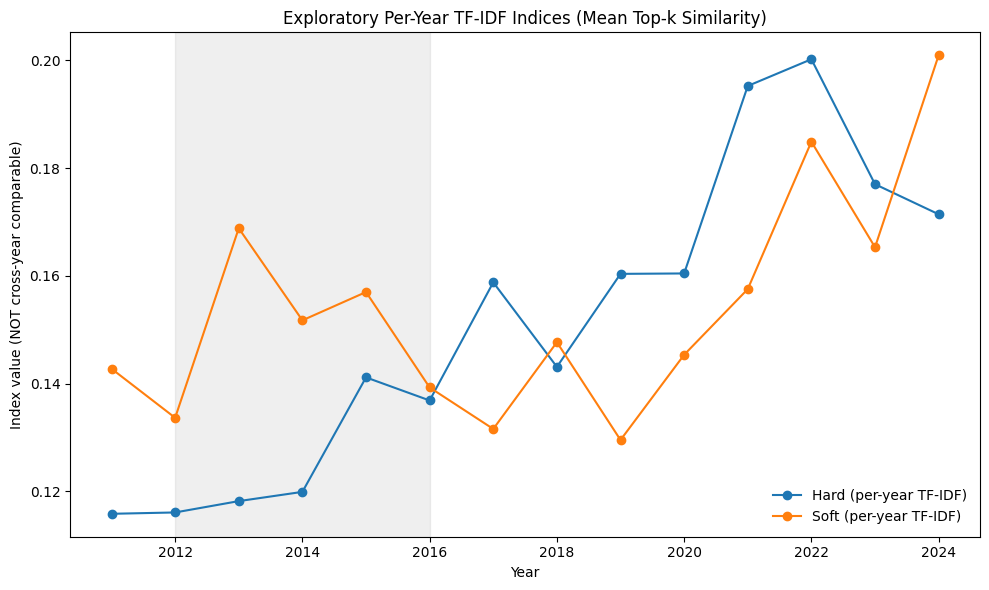

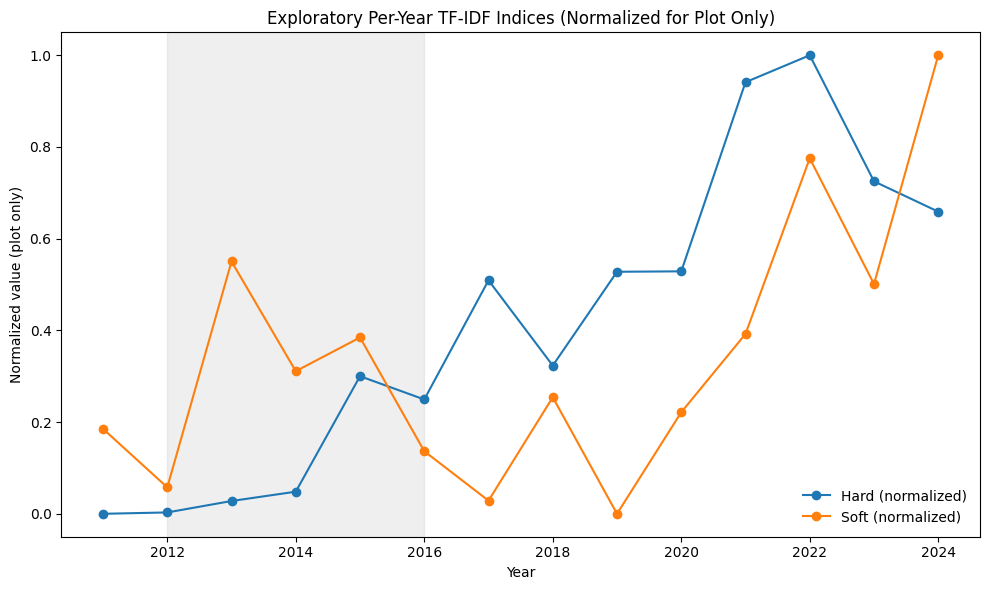

In [10]:
# ============================================================
# SECTION 9 — Exploratory Per-Year Top-K Indices (Not Used in Final Analysis)
#
# NOTE:
# - This section constructs an exploratory metric using per-year TF-IDF.
# - Because TF-IDF is fitted separately each year, similarity scores are NOT
#   cross-year comparable.
# - Therefore, the indices produced here are for method development / sanity
#   checks only, and are NOT used in the final regression analysis.
# ============================================================

# -----------------------------
# Helpers: per-year top-k mean similarity
# -----------------------------
def mean_topk_score_for_query(vect, X, query: str, k: int = 5) -> float:
    """
    Compute mean(top-k) TF-IDF similarity for a single query within one year's TF-IDF space.

    Parameters
    ----------
    vect : TfidfVectorizer
        The TF-IDF vectorizer fitted on that year's chunks.
    X : sparse matrix
        TF-IDF matrix for that year's chunks.
    query : str
        Query text.
    k : int
        Top-k chunks used for averaging.

    Returns
    -------
    float
        Mean of top-k similarity scores (NaN if empty).
    """
    q_vec = vect.transform([query])
    scores = (X @ q_vec.T).toarray().ravel()
    if scores.size == 0:
        return np.nan
    kk = min(k, scores.size)
    topk = np.sort(scores)[-kk:]
    return float(np.mean(topk))


def build_per_year_topk_index(
    year_indexes: dict[int, dict],
    queries: list[str],
    top_k: int = 5
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build an exploratory per-year index using mean(top-k) similarity across queries.

    Parameters
    ----------
    year_indexes : dict
        Output of build_year_indexes(). (per-year TF-IDF spaces)
    queries : list[str]
        Queries defining the distress family.
    top_k : int
        k used in mean(top-k).

    Returns
    -------
    (by_year_query_df, annual_df)
    by_year_query_df: year x query table with avg_topk_similarity
    annual_df: year-level average across queries: distress_index
    """
    rows = []
    for year in sorted(year_indexes.keys()):
        vect = year_indexes[year]["vect"]
        X = year_indexes[year]["X"]

        for q in queries:
            avg_topk = mean_topk_score_for_query(vect, X, q, k=top_k)
            rows.append({"year": year, "query": q, "avg_topk_similarity": avg_topk})

    by_year_query_df = pd.DataFrame(rows)
    annual_df = (
        by_year_query_df.groupby("year")["avg_topk_similarity"]
        .mean()
        .reset_index(name="distress_index_topk_mean")
        .sort_values("year")
    )
    return by_year_query_df, annual_df


def minmax(series: pd.Series) -> pd.Series:
    """Min-max normalize a numeric series (for plotting only)."""
    s = series.astype(float)
    return (s - s.min()) / (s.max() - s.min() + 1e-12)


# -----------------------------
# Execute this section (exploratory outputs)
# -----------------------------

# A) Toy distress queries (you can edit this list; kept small on purpose)
TOY_DISTRESS_QUERIES = [
    "liquidity risk",
    "default on debt",
    "debt covenant compliance",
    "refinancing credit facility",
    "going concern substantial doubt",
]

toy_by_year_query_df, toy_annual_df = build_per_year_topk_index(
    year_indexes,
    TOY_DISTRESS_QUERIES,
    top_k=5
)

toy_by_year_query_df.to_csv("toy_distress_index_by_year_query.csv", index=False, encoding="utf-8-sig")
toy_annual_df.to_csv("toy_distress_index_annual.csv", index=False, encoding="utf-8-sig")
print("Saved: toy_distress_index_by_year_query.csv, toy_distress_index_annual.csv")

display(toy_annual_df.head())

# B) Exploratory Hard/Soft indices (per-year TF-IDF; NOT mainline)
HARD_QUERIES_EXPL = [
    "going concern substantial doubt",
    "event of default default under debt",
    "debt covenant compliance financial covenant",
    "breach violate violation not in compliance covenant",
    "covenant waiver waived waiver of covenant",
    "refinancing credit facility amended credit agreement maturity extended",
    "revolving credit facility revolver",
    "goodwill impairment write down intangible assets impairment",
    "restructuring charges workforce reduction cost reduction",
]

SOFT_QUERIES_EXPL = [
    "loss",
    "net loss",
    "negative operating income operating loss",
    "cash flow pressure",
    "liquidity constraints",
    "cash burn",
    "net cash used in operating activities",
    "decline in cash flows from operations operating cash flow decline",
]

hard_by_yq, hard_annual = build_per_year_topk_index(year_indexes, HARD_QUERIES_EXPL, top_k=3)
soft_by_yq, soft_annual = build_per_year_topk_index(year_indexes, SOFT_QUERIES_EXPL, top_k=3)

hs_expl_annual = (
    hard_annual.rename(columns={"distress_index_topk_mean": "hard_local_topk_mean"})
    .merge(
        soft_annual.rename(columns={"distress_index_topk_mean": "soft_local_topk_mean"}),
        on="year",
        how="outer"
    )
    .sort_values("year")
)

hs_expl_annual.to_csv("exploratory_hard_soft_local_topk.csv", index=False, encoding="utf-8-sig")
print("Saved: exploratory_hard_soft_local_topk.csv (exploratory only)")

display(hs_expl_annual)

# C) Plots (plot only; do NOT interpret as cross-year comparable magnitude)
plt.figure(figsize=(10, 6))
plt.plot(hs_expl_annual["year"], hs_expl_annual["hard_local_topk_mean"], marker="o", label="Hard (per-year TF-IDF)")
plt.plot(hs_expl_annual["year"], hs_expl_annual["soft_local_topk_mean"], marker="o", label="Soft (per-year TF-IDF)")
plt.axvspan(2012, 2016, color="gray", alpha=0.12)
plt.title("Exploratory Per-Year TF-IDF Indices (Mean Top-k Similarity)")
plt.xlabel("Year")
plt.ylabel("Index value (NOT cross-year comparable)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# Normalized plot for shape-only visualization
hs_plot = hs_expl_annual.copy()
hs_plot["hard_norm"] = minmax(hs_plot["hard_local_topk_mean"])
hs_plot["soft_norm"] = minmax(hs_plot["soft_local_topk_mean"])

plt.figure(figsize=(10, 6))
plt.plot(hs_plot["year"], hs_plot["hard_norm"], marker="o", label="Hard (normalized)")
plt.plot(hs_plot["year"], hs_plot["soft_norm"], marker="o", label="Soft (normalized)")
plt.axvspan(2012, 2016, color="gray", alpha=0.12)
plt.title("Exploratory Per-Year TF-IDF Indices (Normalized for Plot Only)")
plt.xlabel("Year")
plt.ylabel("Normalized value (plot only)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# SECTION 10 — Mainline Index Construction (Global TF-IDF + Coverage×Intensity)

Purpose
-------
Build cross-year comparable narrative distress indices by:
 1) pooling all chunks across years into one global TF-IDF space
 2) scoring each chunk against query families (Hard / Soft / Operational)
 3) constructing year-level indices using Coverage × Intensity (CI)

Output
------
- global_chunks_df (chunk-level with scores/flags)
- indices_df (year-level: coverage, intensity, CI indices)
- amd_distress_indices_global_ci.csv  (MAINLINE)

Global chunks: 2431 | years: 2011 - 2024
Global TF-IDF matrix: (2431, 5000)
Thresholds: {'qtl': 0.9, 'hard_thr': 0.12999451860711095, 'soft_thr': 0.11338828046985502, 'oper_thr': 0.14441610302508157}
Saved: amd_distress_indices_global_ci.csv (MAINLINE)
Saved: global_chunks_with_scores_flags.csv (chunk-level)


,year,hard_coverage,hard_intensity,hard_index_ci,soft_coverage,soft_intensity,soft_index_ci,oper_coverage,oper_intensity,oper_index_ci,n_chunks,hard_index_ci_delta,soft_index_ci_delta,oper_index_ci_delta,hard_index_ci_norm,soft_index_ci_norm,oper_index_ci_norm
0,2011,0.054688,0.190066,0.010394,0.132812,0.166141,0.022066,0.101562,0.192767,0.019578,128,NaN,NaN,NaN,0.046826,0.979230,0.210300
1,2012,0.052239,0.166288,0.008687,0.111940,0.158336,0.017724,0.082090,0.190206,0.015614,134,-0.001708,-0.004341,-0.003964,0.000000,0.562515,0.000000
2,2013,0.075342,0.165320,0.012456,0.109589,0.183207,0.020077,0.095890,0.225840,0.021656,146,0.003769,0.002353,0.006042,0.103352,0.788395,0.320545
3,2014,0.093960,0.186248,0.017500,0.114094,0.177807,0.020287,0.107383,0.194956,0.020935,149,0.005044,0.000209,-0.000721,0.241675,0.808486,0.282292
4,2015,0.124183,0.202618,0.025162,0.104575,0.187698,0.019629,0.150327,0.229254,0.034463,153,0.007662,-0.000658,0.013528,0.451780,0.745310,1.000000
5,2016,0.108280,0.196797,0.021309,0.101911,0.166427,0.016961,0.133758,0.238512,0.031903,157,-0.003853,-0.002668,-0.002560,0.346135,0.489224,0.864179
6,2017,0.112426,0.231358,0.026011,0.088757,0.161968,0.014376,0.088757,0.256282,0.022747,169,0.004702,-0.002585,-0.009156,0.475059,0.241119,0.378429
7,2018,0.116279,0.192819,0.022421,0.104651,0.159861,0.016730,0.093023,0.206002,0.019163,172,-0.003590,0.002354,-0.003584,0.376617,0.467043,0.188289
8,2019,0.115607,0.224677,0.025974,0.086705,0.157242,0.013634,0.092486,0.201401,0.018627,173,0.003553,-0.003096,-0.000536,0.474059,0.169875,0.159836
9,2020,0.119048,0.222756,0.026519,0.095238,0.162233,0.015451,0.089286,0.207196,0.018500,168,0.000544,0.001817,-0.000127,0.488985,0.344289,0.153097


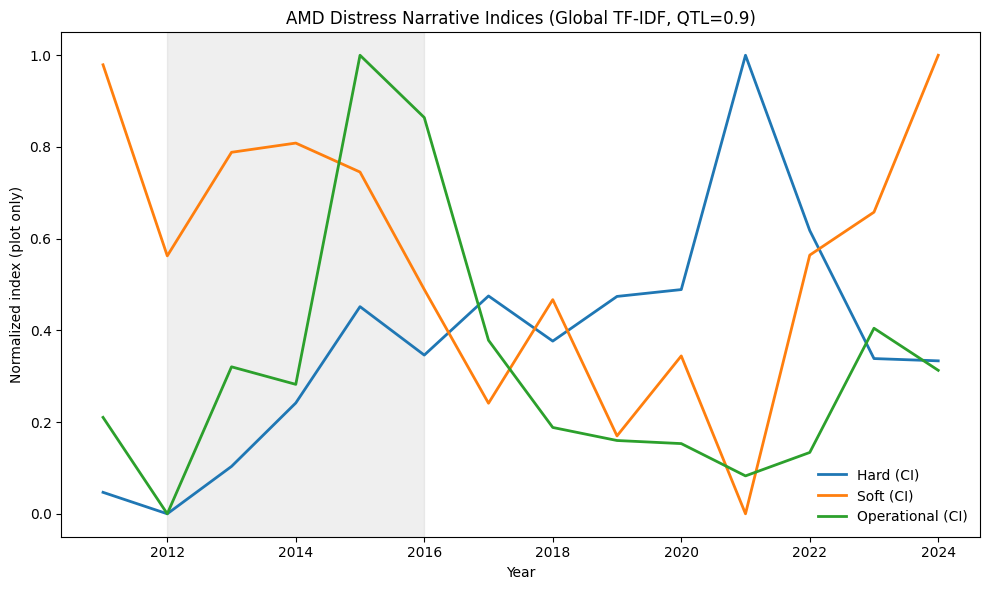

In [11]:
# ============================================================
# SECTION 10 — Mainline Index Construction (Global TF-IDF + Coverage×Intensity)
#
# Purpose
# -------
# Build cross-year comparable narrative distress indices by:
#  1) pooling all chunks across years into one global TF-IDF space
#  2) scoring each chunk against query families (Hard / Soft / Operational)
#  3) constructing year-level indices using Coverage × Intensity (CI)

# Output
# ------
# - global_chunks_df (chunk-level with scores/flags)
# - indices_df (year-level: coverage, intensity, CI indices)
# - amd_distress_indices_global_ci.csv  (MAINLINE)
# ============================================================

# -----------------------------
# Helpers
# -----------------------------
def safe_unique(qs: list[str]) -> list[str]:
    """Deduplicate queries while preserving order; drop empty strings."""
    out, seen = [], set()
    for q in qs:
        q = (q or "").strip()
        if q and q not in seen:
            out.append(q)
            seen.add(q)
    return out


def build_global_corpus(year_indexes: dict[int, dict]) -> pd.DataFrame:
    """
    Concatenate all yearly chunks into a single global corpus.

    Returns
    -------
    pd.DataFrame
        Columns: chunk_id, chunk_text, year
    """
    years_sorted = sorted([y for y in year_indexes.keys() if y is not None])
    all_rows = []
    for y in years_sorted:
        cdf = year_indexes[y]["chunks_df"][["chunk_id", "chunk_text"]].copy()
        cdf["year"] = y
        all_rows.append(cdf)
    global_chunks_df = pd.concat(all_rows, ignore_index=True)
    global_chunks_df["chunk_text"] = global_chunks_df["chunk_text"].fillna("").astype(str)
    global_chunks_df = global_chunks_df[global_chunks_df["chunk_text"].str.strip().astype(bool)].reset_index(drop=True)
    return global_chunks_df


def fit_global_tfidf(global_chunks_df: pd.DataFrame, max_features: int = 5000, ngram_range: tuple[int, int] = (1, 2)):
    """
    Fit one TF-IDF vectorizer on the pooled corpus.

    Returns
    -------
    (vectorizer, X_global)
    """
    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=max_features,
        ngram_range=ngram_range,
        norm="l2",
    )
    X_global = vectorizer.fit_transform(global_chunks_df["chunk_text"].tolist())
    return vectorizer, X_global


def family_max_similarity(X_global, vectorizer: TfidfVectorizer, family_queries: list[str]) -> np.ndarray:
    """
    For each chunk, compute max cosine similarity to a query family.

    Returns
    -------
    np.ndarray shape (n_chunks,)
    """
    family_queries = safe_unique(family_queries)
    if len(family_queries) == 0:
        return np.zeros(X_global.shape[0], dtype=float)

    Q = vectorizer.transform(family_queries)
    # cosine_similarity returns dense; fine for ~2-3k chunks
    sims = cosine_similarity(X_global, Q)
    return sims.max(axis=1)


def add_family_scores(global_chunks_df: pd.DataFrame, X_global, vectorizer: TfidfVectorizer,
                      hard_q: list[str], soft_q: list[str], oper_q: list[str]) -> pd.DataFrame:
    """
    Add hard_score/soft_score/oper_score columns to global_chunks_df.
    """
    df = global_chunks_df.copy()
    df["hard_score"] = family_max_similarity(X_global, vectorizer, hard_q)
    df["soft_score"] = family_max_similarity(X_global, vectorizer, soft_q)
    df["oper_score"] = family_max_similarity(X_global, vectorizer, oper_q)
    return df


def add_global_threshold_flags(global_chunks_df: pd.DataFrame, qtl: float = 0.90) -> tuple[pd.DataFrame, dict]:
    """
    Add boolean flags based on global quantile thresholds.
    Flags mark high-scoring (top tail) chunks for each family.

    Returns
    -------
    (df_with_flags, thresholds_dict)
    """
    df = global_chunks_df.copy()
    hard_thr = df["hard_score"].quantile(qtl)
    soft_thr = df["soft_score"].quantile(qtl)
    oper_thr = df["oper_score"].quantile(qtl)

    df["hard_flag"] = df["hard_score"] >= hard_thr
    df["soft_flag"] = df["soft_score"] >= soft_thr
    df["oper_flag"] = df["oper_score"] >= oper_thr

    thr = {"qtl": qtl, "hard_thr": float(hard_thr), "soft_thr": float(soft_thr), "oper_thr": float(oper_thr)}
    return df, thr


def coverage_intensity(sub_df: pd.DataFrame, score_col: str, flag_col: str) -> tuple[float, float, float]:
    """
    Compute Coverage × Intensity for a given family within a year.

    Coverage  = fraction of chunks flagged True
    Intensity = mean(score | flagged True), 0 if no flagged chunks
    Index     = Coverage * Intensity
    """
    if len(sub_df) == 0:
        return np.nan, np.nan, np.nan

    cov = float(sub_df[flag_col].mean())
    inten = float(sub_df.loc[sub_df[flag_col], score_col].mean()) if sub_df[flag_col].any() else 0.0
    return cov, inten, cov * inten


def build_year_level_ci_indices(global_chunks_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate chunk-level scores/flags into year-level Coverage/Intensity/CI indices.

    Returns
    -------
    pd.DataFrame
        Columns include hard_coverage, hard_intensity, hard_index_ci, etc.
    """
    years_sorted = sorted(global_chunks_df["year"].unique())
    rows = []

    for y in years_sorted:
        sub = global_chunks_df[global_chunks_df["year"] == y]

        hc, hi, hidx = coverage_intensity(sub, "hard_score", "hard_flag")
        sc, si, sidx = coverage_intensity(sub, "soft_score", "soft_flag")
        oc, oi, oidx = coverage_intensity(sub, "oper_score", "oper_flag")

        rows.append({
            "year": int(y),
            "hard_coverage": hc, "hard_intensity": hi, "hard_index_ci": hidx,
            "soft_coverage": sc, "soft_intensity": si, "soft_index_ci": sidx,
            "oper_coverage": oc, "oper_intensity": oi, "oper_index_ci": oidx,
            "n_chunks": int(len(sub)),
        })

    indices_df = pd.DataFrame(rows).sort_values("year").reset_index(drop=True)

    # deltas (optional storytelling feature)
    indices_df["hard_index_ci_delta"] = indices_df["hard_index_ci"].diff()
    indices_df["soft_index_ci_delta"] = indices_df["soft_index_ci"].diff()
    indices_df["oper_index_ci_delta"] = indices_df["oper_index_ci"].diff()

    # normalized columns for plots only
    def _minmax(s: pd.Series) -> pd.Series:
        s = s.astype(float)
        return (s - s.min()) / (s.max() - s.min() + 1e-12)

    indices_df["hard_index_ci_norm"] = _minmax(indices_df["hard_index_ci"])
    indices_df["soft_index_ci_norm"] = _minmax(indices_df["soft_index_ci"])
    indices_df["oper_index_ci_norm"] = _minmax(indices_df["oper_index_ci"])

    return indices_df


# -----------------------------
# Execute this section (MAINLINE)
# -----------------------------

# Use your query families (keep these as your “definition”)
HARD_QUERIES_MAIN = [
    "going concern substantial doubt",
    "event of default default under debt",
    "debt covenant compliance financial covenant",
    "breach violate violation not in compliance covenant",
    "covenant waiver waived waiver of covenant",
    "refinancing credit facility amended credit agreement maturity extended",
    "revolving credit facility revolver",
    "goodwill impairment write down intangible assets impairment",
    "restructuring charges workforce reduction cost reduction",
]

SOFT_QUERIES_MAIN = [
    "loss",
    "net loss",
    "negative operating income operating loss",
    "cash flow pressure",
    "liquidity constraints",
    "cash burn",
    "net cash used in operating activities",
    "decline in cash flows from operations operating cash flow decline",
]

OPERATIONAL_QUERIES_MAIN = [
    "operating loss",
    "net loss",
    "negative cash flow",
    "decline in revenue",
    "decrease in revenue",
    "revenue decline",
    "decline in gross margin",
    "margin erosion",
    "competitive pressure",
    "loss of market share",
    "pricing pressure",
    "restructuring",
    "cost reduction",
    "workforce reduction",
    "impairment charge",
]

# 1) Build global corpus
global_chunks_df = build_global_corpus(year_indexes)
print("Global chunks:", len(global_chunks_df), "| years:", global_chunks_df["year"].min(), "-", global_chunks_df["year"].max())

# 2) Fit global TF-IDF
vectorizer_global, X_global = fit_global_tfidf(global_chunks_df, max_features=5000, ngram_range=(1, 2))
print("Global TF-IDF matrix:", X_global.shape)

# 3) Score chunk-level similarities
global_chunks_df = add_family_scores(
    global_chunks_df,
    X_global,
    vectorizer_global,
    hard_q=HARD_QUERIES_MAIN,
    soft_q=SOFT_QUERIES_MAIN,
    oper_q=OPERATIONAL_QUERIES_MAIN
)

# 4) Threshold flags (global quantiles)
QTL = 0.90  # tune if needed (0.85/0.90/0.95)
global_chunks_df, thresholds = add_global_threshold_flags(global_chunks_df, qtl=QTL)
print("Thresholds:", thresholds)

# 5) Year-level indices (Coverage×Intensity)
indices_df = build_year_level_ci_indices(global_chunks_df)

# Save mainline outputs
indices_df.to_csv("amd_distress_indices_global_ci.csv", index=False, encoding="utf-8-sig")
global_chunks_df.to_csv("global_chunks_with_scores_flags.csv", index=False, encoding="utf-8-sig")
print("Saved: amd_distress_indices_global_ci.csv (MAINLINE)")
print("Saved: global_chunks_with_scores_flags.csv (chunk-level)")

display(indices_df)

# 6) Quick plot (normalized; plot only)
plt.figure(figsize=(10, 6))
plt.plot(indices_df["year"], indices_df["hard_index_ci_norm"], linewidth=2, label="Hard (CI)")
plt.plot(indices_df["year"], indices_df["soft_index_ci_norm"], linewidth=2, label="Soft (CI)")
plt.plot(indices_df["year"], indices_df["oper_index_ci_norm"], linewidth=2, label="Operational (CI)")
plt.axvspan(2012, 2016, color="gray", alpha=0.12)
plt.title(f"AMD Distress Narrative Indices (Global TF-IDF, QTL={QTL})")
plt.xlabel("Year")
plt.ylabel("Normalized index (plot only)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# SECTION 11 — Market Integration & Regression Tests
Purpose
-------
1) Load AMD / SPX total return index data
2) Compute monthly abnormal returns (AMD - SPX)
3) Compute forward abnormal returns (6M, 12M)
4) Merge with MAINLINE indices_df (Global TF-IDF + CI)
5) Run association checks (Spearman, median split) + OLS regressions
6) Produce report-ready visuals + export results tables

Output
------
- annual_with_indices_and_returns.csv
- reg_spearman_summary.csv
- figures shown inline

Saved: annual_with_indices_and_returns.csv


,year,hard_coverage,hard_intensity,hard_index_ci,soft_coverage,soft_intensity,soft_index_ci,oper_coverage,oper_intensity,oper_index_ci,n_chunks,hard_index_ci_delta,soft_index_ci_delta,oper_index_ci_delta,hard_index_ci_norm,soft_index_ci_norm,oper_index_ci_norm,filing_date,ym,fwd_12m_abret,fwd_6m_abret,fwd_12m_ret,decline_12m,decline_12m_20
0,2011,0.054688,0.190066,0.010394,0.132812,0.166141,0.022066,0.101562,0.192767,0.019578,128,NaN,NaN,NaN,0.046826,0.979230,0.210300,2011-02-28,2011-02,-0.176337,-0.195704,-0.113950,1.0,0.0
1,2012,0.052239,0.166288,0.008687,0.111940,0.158336,0.017724,0.082090,0.190206,0.015614,134,-0.001708,-0.004341,-0.003964,0.000000,0.562515,0.000000,2012-02-28,2012-02,-1.010191,-0.641913,-0.878481,1.0,1.0
2,2013,0.075342,0.165320,0.012456,0.109589,0.183207,0.020077,0.095890,0.225840,0.021656,146,0.003769,0.002353,0.006042,0.103352,0.788395,0.320545,2013-02-28,2013-02,0.375561,0.418361,0.579301,0.0,0.0
3,2014,0.093960,0.186248,0.017500,0.114094,0.177807,0.020287,0.107383,0.194956,0.020935,149,0.005044,0.000209,-0.000721,0.241675,0.808486,0.282292,2014-02-28,2014-02,-0.257369,0.039848,-0.109080,1.0,1.0
4,2015,0.124183,0.202618,0.025162,0.104575,0.187698,0.019629,0.150327,0.229254,0.034463,153,0.007662,-0.000658,0.013528,0.451780,0.745310,1.000000,2015-02-28,2015-02,-0.183737,-0.439406,-0.240087,1.0,0.0
5,2016,0.108280,0.196797,0.021309,0.101911,0.166427,0.016961,0.133758,0.238512,0.031903,157,-0.003853,-0.002668,-0.002560,0.346135,0.489224,0.864179,2016-02-28,2016-02,1.968955,1.272252,2.196843,0.0,0.0
6,2017,0.112426,0.231358,0.026011,0.088757,0.161968,0.014376,0.088757,0.256282,0.022747,169,0.004702,-0.002585,-0.009156,0.475059,0.241119,0.378429,2017-02-28,2017-02,-0.243134,-0.132701,-0.081708,1.0,1.0
7,2018,0.116279,0.192819,0.022421,0.104651,0.159861,0.016730,0.093023,0.206002,0.019163,172,-0.003590,0.002354,-0.003584,0.376617,0.467043,0.188289,2018-02-28,2018-02,1.153329,1.149975,1.256240,0.0,0.0
8,2019,0.115607,0.224677,0.025974,0.086705,0.157242,0.013634,0.092486,0.201401,0.018627,173,0.003553,-0.003096,-0.000536,0.474059,0.169875,0.159836,2019-02-28,2019-02,0.623291,0.237373,0.712696,0.0,0.0
9,2020,0.119048,0.222756,0.026519,0.095238,0.162233,0.015451,0.089286,0.207196,0.018500,168,0.000544,0.001817,-0.000127,0.488985,0.344289,0.153097,2020-02-28,2020-02,0.462421,0.600970,0.763564,0.0,0.0



=== Spearman vs fwd_12m_abret ===
hard: 0.3098901098901099
soft: -0.4153846153846154
oper: 0.16483516483516483

=== Spearman vs fwd_6m_abret ===
hard: 0.23516483516483516
soft: -0.3978021978021978
oper: 0.14725274725274726

=== High vs Low (median split), 12m ===
hard median: 0.021864986999302456 
 high
False    0.151615
True     0.263518
Name: fwd_12m_abret, dtype: float64
soft median: 0.01773258935606102 
 high
False    0.451664
True    -0.036531
Name: fwd_12m_abret, dtype: float64
oper median: 0.02025636251748783 
 high
False    0.154995
True     0.260137
Name: fwd_12m_abret, dtype: float64

================ OLS: fwd_12m_abret ================

--- hard_index_ci ---
                            OLS Regression Results                            
Dep. Variable:          fwd_12m_abret   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                 -0.046
Method:                 Least Squares   F-statistic:                    0.4267
Date:

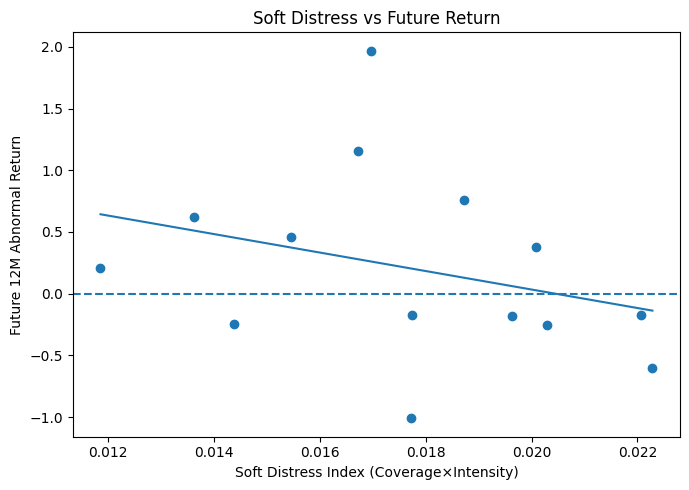

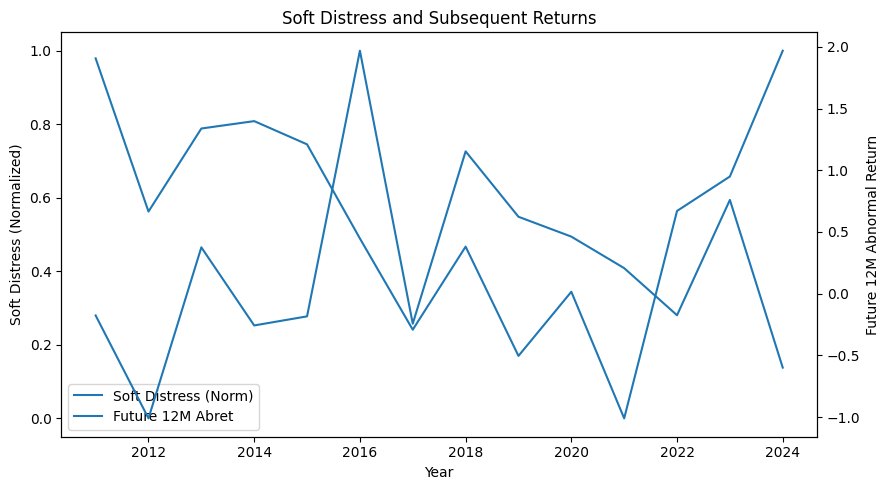

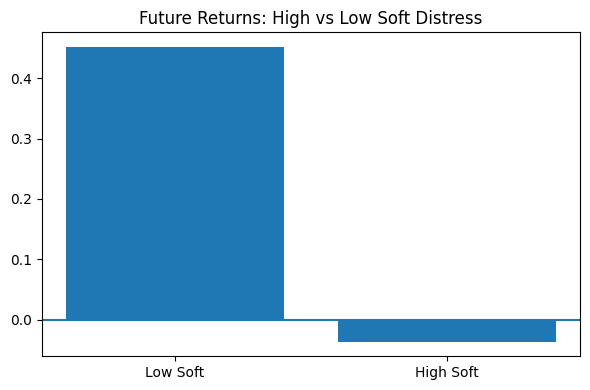

Saved: reg_spearman_summary.csv


,horizon,x,n,beta,t,p,r2,spearman
0,fwd_12m_abret,hard_index_ci,14,15.325242,0.653218,0.525934,0.034337,0.309890
1,fwd_12m_abret,soft_index_ci,14,-74.959285,-1.109694,0.288874,0.093068,-0.415385
2,fwd_12m_abret,oper_index_ci,14,50.961714,1.325122,0.209809,0.127650,0.164835
3,fwd_6m_abret,hard_index_ci,14,7.158908,0.418233,0.683164,0.014367,0.235165
4,fwd_6m_abret,soft_index_ci,14,-45.950661,-0.928742,0.371328,0.067060,-0.397802
5,fwd_6m_abret,oper_index_ci,14,17.547869,0.598883,0.560387,0.029021,0.147253


In [12]:
# ============================================================
# SECTION 11 — Market Integration & Regression Tests
#
# Purpose
# -------
# 1) Load AMD / SPX total return index data
# 2) Compute monthly abnormal returns (AMD - SPX)
# 3) Compute forward abnormal returns (6M, 12M)
# 4) Merge with MAINLINE indices_df (Global TF-IDF + CI)
# 5) Run association checks (Spearman, median split) + OLS regressions
# 6) Produce report-ready visuals + export results tables

# Output
# ------
# - annual_with_indices_and_returns.csv
# - reg_spearman_summary.csv
# - figures shown inline
# ============================================================

# -----------------------------
# Helpers
# -----------------------------
def load_price_data(amd_path: str, spx_path: str) -> pd.DataFrame:
    """
    Load AMD and SPX total return index files, compute monthly returns and abnormal return.

    Expected columns
    ----------------
    AMD.xlsx: Date, TOT_RETURN_INDEX_GROSS_DVDS
    spx.xlsx: Date, TOT_RETURN_INDEX_GROSS_DVDS

    Returns
    -------
    pd.DataFrame
        Columns: Date, ret_amd, ret_spx, abret, ym
    """
    amd_px = pd.read_excel(amd_path).sort_values("Date").reset_index(drop=True)
    spx_px = pd.read_excel(spx_path).sort_values("Date").reset_index(drop=True)

    amd_px["Date"] = pd.to_datetime(amd_px["Date"])
    spx_px["Date"] = pd.to_datetime(spx_px["Date"])

    amd_px["ret_amd"] = amd_px["TOT_RETURN_INDEX_GROSS_DVDS"].pct_change()
    spx_px["ret_spx"] = spx_px["TOT_RETURN_INDEX_GROSS_DVDS"].pct_change()

    amd_px = amd_px.dropna(subset=["ret_amd"]).copy()
    spx_px = spx_px.dropna(subset=["ret_spx"]).copy()

    price_df = amd_px.merge(spx_px[["Date", "ret_spx"]], on="Date", how="inner")
    price_df["abret"] = price_df["ret_amd"] - price_df["ret_spx"]  # monthly abnormal return
    price_df = price_df.sort_values("Date").reset_index(drop=True)

    price_df["ym"] = price_df["Date"].dt.to_period("M")
    return price_df


def add_forward_returns(price_df: pd.DataFrame) -> pd.DataFrame:
    """
    Add forward cumulative abnormal returns using rolling sums.

    Notes
    -----
    This matches your current notebook method:
    fwd_12m_abret = sum(abret over next 12 months)
    fwd_6m_abret  = sum(abret over next 6 months)
    """
    df = price_df.copy()
    df["fwd_12m_abret"] = df["abret"].rolling(12).sum().shift(-12)
    df["fwd_6m_abret"]  = df["abret"].rolling(6).sum().shift(-6)
    df["fwd_12m_ret"]   = df["ret_amd"].rolling(12).sum().shift(-12)
    return df


def merge_indices_with_returns(indices_df: pd.DataFrame, price_df: pd.DataFrame, filing_month: str = "02-28") -> pd.DataFrame:
    """
    Merge year-level narrative indices with forward return measures.

    Because exact filing date is not used here, we approximate the filing month as YYYY-02-28.
    Then we map it to ym (Period[M]) and merge on monthly forward returns.

    Returns
    -------
    pd.DataFrame
        annual_df with indices + forward returns
    """
    annual_df = indices_df.copy()
    annual_df["filing_date"] = pd.to_datetime(annual_df["year"].astype(str) + f"-{filing_month}")
    annual_df["ym"] = annual_df["filing_date"].dt.to_period("M")

    annual_df = annual_df.merge(
        price_df[["ym", "fwd_12m_abret", "fwd_6m_abret", "fwd_12m_ret"]],
        on="ym",
        how="left"
    )
    return annual_df


def spearman_pair(df: pd.DataFrame, x: str, y: str) -> float:
    """Compute Spearman correlation for two columns (drop NaNs)."""
    tmp = df[[x, y]].dropna()
    if len(tmp) < 3:
        return np.nan
    return float(tmp.corr(method="spearman").iloc[0, 1])


def median_split_means(df: pd.DataFrame, x: str, y: str) -> tuple[float, pd.Series]:
    """
    Split by median of x and compute mean of y in high/low groups.
    Returns (median, means_series indexed by high flag).
    """
    tmp = df[[x, y]].dropna().copy()
    med = float(tmp[x].median())
    tmp["high"] = tmp[x] > med
    means = tmp.groupby("high")[y].mean()
    return med, means


def run_ols(df: pd.DataFrame, x: str, y: str):
    """
    Run OLS: y ~ const + x, dropping NaNs.
    Returns fitted statsmodels model.
    """
    tmp = df[[x, y]].dropna()
    X = sm.add_constant(tmp[[x]])
    model = sm.OLS(tmp[y], X).fit()
    return model


def export_reg_summary(annual_df: pd.DataFrame, horizons: list[str], xs: list[str], out_csv: str = "reg_spearman_summary.csv") -> pd.DataFrame:
    """
    Export a compact regression + Spearman summary table.
    """
    out_rows = []
    for horizon in horizons:
        for x in xs:
            tmp = annual_df[[x, horizon]].dropna()
            if len(tmp) < 3:
                continue
            m = run_ols(annual_df, x, horizon)
            out_rows.append({
                "horizon": horizon,
                "x": x,
                "n": int(m.nobs),
                "beta": float(m.params[x]),
                "t": float(m.tvalues[x]),
                "p": float(m.pvalues[x]),
                "r2": float(m.rsquared),
                "spearman": float(tmp.corr(method="spearman").iloc[0, 1]),
            })

    results_df = pd.DataFrame(out_rows)
    results_df.to_csv(out_csv, index=False, encoding="utf-8-sig")
    print(f"Saved: {out_csv}")
    return results_df


# -----------------------------
# Execute this section
# -----------------------------

# 0) Load + compute abnormal + forward returns
AMD_XLSX = "data/AMD.xlsx"
SPX_XLSX = "data/spx.xlsx"

assert Path(AMD_XLSX).exists(), f"Missing file: {AMD_XLSX}"
assert Path(SPX_XLSX).exists(), f"Missing file: {SPX_XLSX}"

price_df = load_price_data(AMD_XLSX, SPX_XLSX)
price_df = add_forward_returns(price_df)

# 1) Merge with MAINLINE indices (indices_df from Section 10)
annual_df = merge_indices_with_returns(indices_df, price_df, filing_month="02-28")

# optional classification labels
annual_df["decline_12m"] = np.where(
    annual_df["fwd_12m_abret"].notna(),
    (annual_df["fwd_12m_abret"] < 0).astype(int),
    np.nan
)
annual_df["decline_12m_20"] = np.where(
    annual_df["fwd_12m_abret"].notna(),
    (annual_df["fwd_12m_abret"] < -0.20).astype(int),
    np.nan
)

annual_df.to_csv("annual_with_indices_and_returns.csv", index=False, encoding="utf-8-sig")
print("Saved: annual_with_indices_and_returns.csv")
display(annual_df)

# 2) Spearman correlations
for horizon in ["fwd_12m_abret", "fwd_6m_abret"]:
    print(f"\n=== Spearman vs {horizon} ===")
    print("hard:", spearman_pair(annual_df, "hard_index_ci", horizon))
    print("soft:", spearman_pair(annual_df, "soft_index_ci", horizon))
    print("oper:", spearman_pair(annual_df, "oper_index_ci", horizon))

# 3) High vs Low (median split)
print("\n=== High vs Low (median split), 12m ===")
med_hard, means_hard_12 = median_split_means(annual_df, "hard_index_ci", "fwd_12m_abret")
med_soft, means_soft_12 = median_split_means(annual_df, "soft_index_ci", "fwd_12m_abret")
med_oper, means_oper_12 = median_split_means(annual_df, "oper_index_ci", "fwd_12m_abret")
print("hard median:", med_hard, "\n", means_hard_12)
print("soft median:", med_soft, "\n", means_soft_12)
print("oper median:", med_oper, "\n", means_oper_12)

annual_df["high_hard"] = annual_df["hard_index_ci"] > annual_df["hard_index_ci"].median()
annual_df["high_soft"] = annual_df["soft_index_ci"] > annual_df["soft_index_ci"].median()
annual_df["high_oper"] = annual_df["oper_index_ci"] > annual_df["oper_index_ci"].median()

# 4) OLS regressions
for horizon in ["fwd_12m_abret", "fwd_6m_abret"]:
    print(f"\n================ OLS: {horizon} ================")
    for x in ["hard_index_ci", "soft_index_ci", "oper_index_ci"]:
        m = run_ols(annual_df, x, horizon)
        print(f"\n--- {x} ---")
        print(m.summary())

# 5) Report-ready visuals (example focuses on SOFT)
# 5.1 Scatter + regression line
tmp = annual_df[["soft_index_ci", "fwd_12m_abret"]].dropna().copy()
plt.figure(figsize=(7, 5))
plt.scatter(tmp["soft_index_ci"], tmp["fwd_12m_abret"])
m_slope, b_intercept = np.polyfit(tmp["soft_index_ci"], tmp["fwd_12m_abret"], 1)
xline = np.linspace(tmp["soft_index_ci"].min(), tmp["soft_index_ci"].max(), 50)
plt.plot(xline, m_slope * xline + b_intercept)
plt.axhline(0, linestyle="--")
plt.xlabel("Soft Distress Index (Coverage×Intensity)")
plt.ylabel("Future 12M Abnormal Return")
plt.title("Soft Distress vs Future Return")
plt.tight_layout()
plt.show()

# 5.2 Time series: soft index vs subsequent returns (dual axis)
tmp2 = annual_df[["year", "soft_index_ci_norm", "fwd_12m_abret"]].dropna().copy()
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(tmp2["year"], tmp2["soft_index_ci_norm"], label="Soft Distress (Norm)")
ax1.set_ylabel("Soft Distress (Normalized)")
ax1.set_xlabel("Year")

ax2 = ax1.twinx()
ax2.plot(tmp2["year"], tmp2["fwd_12m_abret"], label="Future 12M Abret")
ax2.set_ylabel("Future 12M Abnormal Return")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title("Soft Distress and Subsequent Returns")
plt.tight_layout()
plt.show()

# 5.3 Bar: high vs low soft distress
means = annual_df.dropna(subset=["soft_index_ci", "fwd_12m_abret"]).groupby("high_soft")["fwd_12m_abret"].mean()
plt.figure(figsize=(6, 4))
plt.bar(["Low Soft", "High Soft"], means.values)
plt.axhline(0)
plt.title("Future Returns: High vs Low Soft Distress")
plt.tight_layout()
plt.show()

# 6) Export compact results table
results_df = export_reg_summary(
    annual_df,
    horizons=["fwd_12m_abret", "fwd_6m_abret"],
    xs=["hard_index_ci", "soft_index_ci", "oper_index_ci"],
    out_csv="reg_spearman_summary.csv"
)
display(results_df)

# SECTION 12 — Summary & Interpretation

## What we built
This notebook constructs a narrative-based financial distress signal from AMD 10-K Item 1A (Risk Factors). We first validate retrieval quality (TF-IDF top-k chunks + human labels), then build cross-year comparable distress indices using a single global TF-IDF space and a Coverage×Intensity (CI) aggregation at the year level.

## Retrieval layer sanity & evaluation
A manual sanity check shows TF-IDF top results align with the intended query semantics (e.g., liquidity-related language ranks higher with monotonically decreasing scores). Using human-labeled samples, precision@k varies across query families, with stronger performance on more explicit “hard” phrases (e.g., default/impairment terminology) and weaker performance on softer, more diffuse language.

## Mainline index construction (used in analysis)
Our final indices are computed in a global TF-IDF space (pooled chunks across 2011–2024), producing Hard / Soft / Operational distress measures per year. We use global quantile thresholds to define coverage (share of high-scoring chunks) and intensity (mean score among flagged chunks), and combine them as CI = Coverage × Intensity.

## Relationship to subsequent returns (exploratory econometrics)
We merge annual indices with forward abnormal returns (AMD minus SPX) using an approximate filing month mapping. The Soft index shows a negative association with future abnormal returns (Spearman ≈ -0.41 for 12M; ≈ -0.40 for 6M), consistent with the intuition that more negative narrative signals may precede weaker performance. However, OLS estimates are not statistically significant, likely due to the small annual sample size (n=14) and noise in the timing alignment.

## Limitations
The analysis is limited by the small annual sample size (2011–2024) and approximate filing-date alignment, so results should be interpreted as exploratory rather than definitive.